In [21]:
import radarsimpy

print("`RadarSimPy` used in this example is version: " + str(radarsimpy.__version__))

`RadarSimPy` used in this example is version: 15.2.0


# Stripmap SAR Survey of the Grand Canyon

This notebook extends the companion [waveform_lfm_sar.ipynb](waveform_lfm_sar.ipynb) notebook — same C-band LFM chirp waveform, same stretch/deramp receiver model, same Back-Projection (BPA) focusing — but replaces the three idealized point targets with a **real 3-D terrain mesh**: `grand_canyon.stl`, a ~50 km × 62 km digital elevation model of the Grand Canyon with over 770,000 triangular facets (the same terrain model used in [scene_pulse_radar_altimeter.ipynb](scene_pulse_radar_altimeter.ipynb)).

Flying a synthetic side-looking radar over real, richly-varying terrain — rather than isolated point scatterers on a flat plane — exposes a phenomenon invisible in the flat-earth point-target case: **relief displacement (layover)**. Back-Projection has to assume some reference ground elevation to convert range into an image pixel; wherever the true terrain elevation departs from that reference — as it dramatically does inside a canyon — the returned energy is placed at the *wrong* range in the image. Tall rims lean toward the radar; canyon floors lean away. This is exactly what real airborne and spaceborne SAR systems contend with when imaging mountainous terrain, and it's the central lesson of this notebook.

## What's different from the point-target notebook

| | `waveform_lfm_sar.ipynb` | This notebook |
|---|---|---|
| Target | 3 ideal point scatterers | `grand_canyon.stl` — real terrain, ray-traced |
| Scene relief | Flat, z = 0 everywhere | ≈1,100 m of local vertical relief |
| Geometry | Flat 2-D (broadside, no altitude) | Full 3-D side-looking stripmap (altitude + depression angle) |
| Key artifact | None (ideal focusing) | Layover / relief displacement |
| Antenna | Wide azimuth, narrow elevation (flat scene) | Narrow azimuth (real 1.5 m aperture), **wide elevation** (must span the swath's depression-angle spread) |

## Workflow

```
Scout the STL for a good canyon cross-section → LFM waveform + side-looking flight geometry
    → Transmitter / Receiver → sim_radar() over the real mesh
    → Range Compression (fast-time FFT) → Back-Projection → SAR image
    → Compare true terrain elevation vs. imaged position (layover check)
```

## Setup

In [22]:
import time
import numpy as np
import scipy
from scipy import constants
from scipy.interpolate import interp1d
from scipy.signal import find_peaks
import plotly.graph_objs as go
from plotly.subplots import make_subplots
from IPython.display import Image, display
import pymeshlab
from radarsimpy import Radar, Transmitter, Receiver
from radarsimpy.simulator import sim_radar

# Set to True for interactive plots; False renders a static JPEG (e.g. for HTML export)
INTERACTIVE = False


def show(fig):
    if INTERACTIVE:
        fig.show()
    else:
        display(Image(fig.to_image(format="jpg", scale=2)))

## Terrain Reconnaissance: Scouting `grand_canyon.stl`

Before designing the radar, we scout the terrain model itself. `grand_canyon.stl` covers a huge footprint — flying and imaging the *entire* thing at meter-scale SAR resolution is neither realistic nor tractable in a demo notebook (a real spaceborne SAR swath is typically tens of km wide, not thousands). Instead, we survey a compact, richly-varying **canyon cross-section** that shows dramatic relief in a small footprint.

grand_canyon.stl: 771,288 faces, 386,884 vertices
  x range: -1 to 49947 m  (49.9 km)
  y range: -1 to 61900 m  (61.9 km)
  z range (elevation): -1 to 2407 m


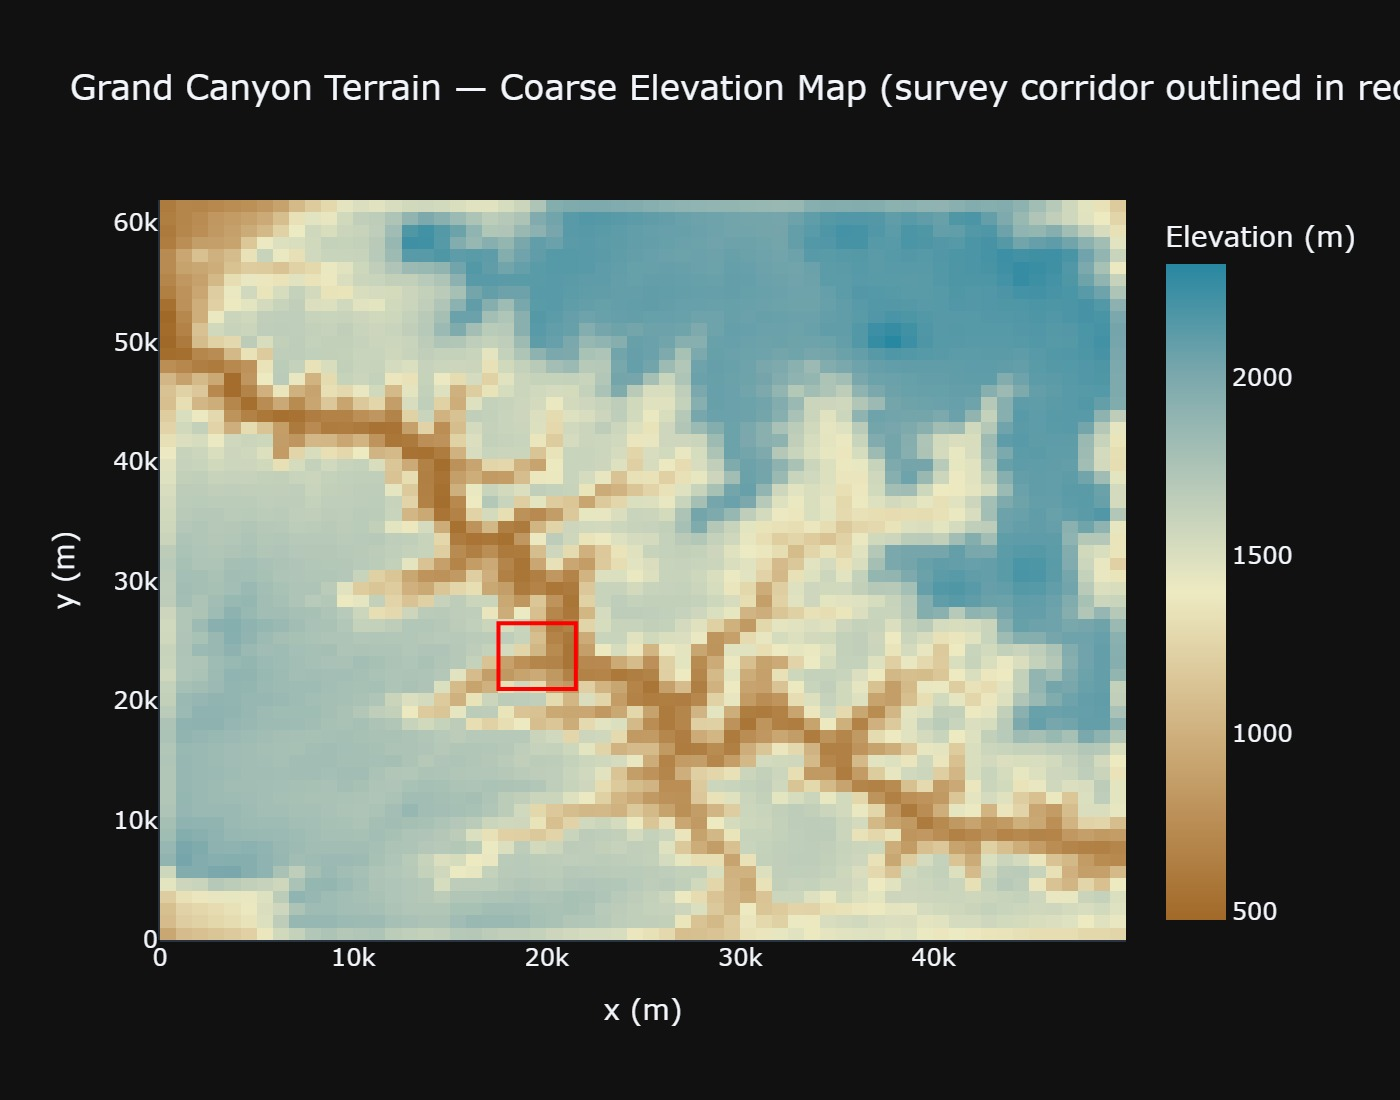

In [23]:
ms = pymeshlab.MeshSet()
ms.load_new_mesh("../models/grand_canyon.stl")
mesh = ms.current_mesh()
verts = np.array(mesh.vertex_matrix())
faces = np.array(mesh.face_matrix())

print(f"grand_canyon.stl: {faces.shape[0]:,} faces, {verts.shape[0]:,} vertices")
print(f"  x range: {verts[:,0].min():.0f} to {verts[:,0].max():.0f} m  "
      f"({(verts[:,0].max()-verts[:,0].min())/1000:.1f} km)")
print(f"  y range: {verts[:,1].min():.0f} to {verts[:,1].max():.0f} m  "
      f"({(verts[:,1].max()-verts[:,1].min())/1000:.1f} km)")
print(f"  z range (elevation): {verts[:,2].min():.0f} to {verts[:,2].max():.0f} m")

# Coarse binned elevation map (mean z per ~1 km cell) — orientation only, not for imaging
nbins = 60
xedges = np.linspace(verts[:, 0].min(), verts[:, 0].max(), nbins + 1)
yedges = np.linspace(verts[:, 1].min(), verts[:, 1].max(), nbins + 1)
xi = np.clip(np.digitize(verts[:, 0], xedges) - 1, 0, nbins - 1)
yi = np.clip(np.digitize(verts[:, 1], yedges) - 1, 0, nbins - 1)
counts = np.zeros((nbins, nbins))
zsum = np.zeros((nbins, nbins))
np.add.at(counts, (xi, yi), 1)
np.add.at(zsum, (xi, yi), verts[:, 2])
zmean = np.full((nbins, nbins), np.nan)
valid = counts > 0
zmean[valid] = zsum[valid] / counts[valid]

fig = go.Figure(
    go.Heatmap(
        x=(xedges[:-1] + xedges[1:]) / 2,
        y=(yedges[:-1] + yedges[1:]) / 2,
        z=zmean.T,
        colorscale="Earth",
        colorbar=dict(title="Elevation (m)"),
    )
)
fig.add_shape(
    type="rect", x0=17500, x1=21500, y0=21000, y1=26500,
    line=dict(color="red", width=2), fillcolor="rgba(0,0,0,0)",
)
fig.update_layout(
    title="Grand Canyon Terrain — Coarse Elevation Map (survey corridor outlined in red)",
    xaxis_title="x (m)",
    yaxis_title="y (m)",
    template="plotly_dark",
    height=550,
)
show(fig)

### Selected Survey Corridor

Within the outlined box we pick a cross-canyon corridor with strong relief: elevation swings from **≈531 m** (canyon floor) up to **≈1,655 m** (rim) over roughly 3.5 km of cross-track distance — about **1,100 m of vertical relief**, comparable to the real Grand Canyon's inner gorge.

| Parameter | Value |
|---|---|
| Azimuth (along-track) reference `cx` | 19,479 m |
| Cross-track survey swath `y` | 22,000 – 25,500 m |
| Local elevation range | ≈531 – 1,655 m |

Vertices in local survey area: 2800
  Local elevation: 482 to 1689 m


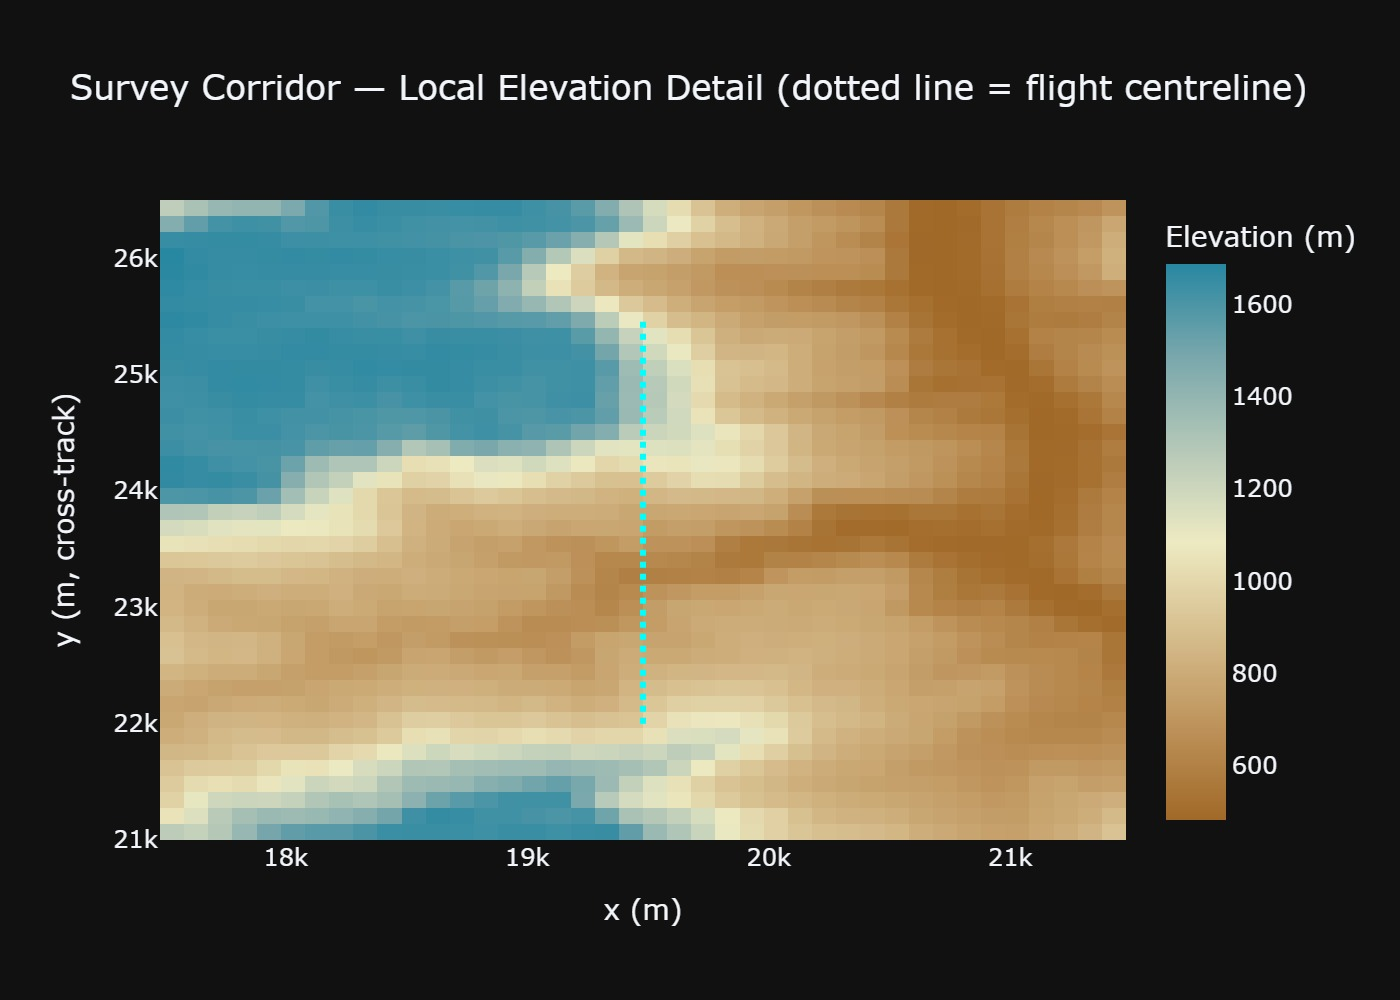

In [24]:
cx = 19479.0
y0, y1 = 22000.0, 25500.0

aoi_mask = (
    (verts[:, 0] >= cx - 2000) & (verts[:, 0] <= cx + 2000)
    & (verts[:, 1] >= y0 - 1000) & (verts[:, 1] <= y1 + 1000)
)
print(f"Vertices in local survey area: {aoi_mask.sum()}")
print(f"  Local elevation: {verts[aoi_mask, 2].min():.0f} to {verts[aoi_mask, 2].max():.0f} m")

nbins2 = 40
xe2 = np.linspace(cx - 2000, cx + 2000, nbins2 + 1)
ye2 = np.linspace(y0 - 1000, y1 + 1000, nbins2 + 1)
xi2 = np.clip(np.digitize(verts[aoi_mask, 0], xe2) - 1, 0, nbins2 - 1)
yi2 = np.clip(np.digitize(verts[aoi_mask, 1], ye2) - 1, 0, nbins2 - 1)
counts2 = np.zeros((nbins2, nbins2))
zsum2 = np.zeros((nbins2, nbins2))
np.add.at(counts2, (xi2, yi2), 1)
np.add.at(zsum2, (xi2, yi2), verts[aoi_mask, 2])
zmean2 = np.full((nbins2, nbins2), np.nan)
valid2 = counts2 > 0
zmean2[valid2] = zsum2[valid2] / counts2[valid2]

fig = go.Figure(
    go.Heatmap(
        x=(xe2[:-1] + xe2[1:]) / 2,
        y=(ye2[:-1] + ye2[1:]) / 2,
        z=zmean2.T,
        colorscale="Earth",
        colorbar=dict(title="Elevation (m)"),
    )
)
fig.add_shape(
    type="line", x0=cx, x1=cx, y0=y0, y1=y1,
    line=dict(color="cyan", width=3, dash="dot"),
)
fig.update_layout(
    title="Survey Corridor — Local Elevation Detail (dotted line = flight centreline)",
    xaxis_title="x (m)",
    yaxis_title="y (m, cross-track)",
    template="plotly_dark",
    height=500,
)
show(fig)

### Waveform, Flight Geometry & Sampling Parameters

Same **C-band LFM chirp** as the point-target notebook (`fc` = 4 GHz, `B` = 50 MHz → ΔR = 3 m), but the **pulse duration is stretched to 10 μs** (instead of 3 μs). Because RadarSimPy's chirp receiver reports range via an *absolute* beat frequency, the required sample rate scales with the maximum range and *inversely* with pulse duration — the several-kilometer slant range here (vs. ~1 km before) would otherwise demand a ~1.3 GHz sample rate. Stretching the chirp brings that back down to a manageable ~400 MHz.

This is also genuinely a **3-D side-looking stripmap** geometry now: the platform flies at altitude with a lateral standoff from the swath, so every pixel has both a cross-track ground distance *and* a vertical offset — unlike the flat, altitude-free 2-D geometry in the point-target notebook.

> **Proper stripmap focusing: a sliding aperture, not one global sum.** Earlier passes through this notebook summed the *entire* flight as one synthetic aperture for every pixel (spotlight-style), which forced pulse count to scale with the *square* of the aperture length. Real stripmap SAR doesn't do that: a ground point is only ever illuminated while it sits inside the antenna's **real-beam footprint** (length ≈ Rλ/Dₐ), so each pixel only needs the pulses from *its own* local dwell — a sliding window, not the whole flight. PRF only needs to satisfy the *local* Nyquist criterion `PRF > 2v/Dₐ`, so pulse count now grows only linearly with swath length. The trade-off: azimuth resolution is fixed at the real-aperture limit `Δaz = Dₐ/2` everywhere (0.75 m for our 1.5 m antenna) — coarser than a spotlight-style number would report, but the physically honest value.
>
> **A second, independent limit: simulated flight duration.** This evaluation build of `sim_radar` also silently stops updating platform motion once the simulated timeline exceeds ≈5.0 seconds — pulses beyond that point quietly return stale, bit-for-bit identical data instead of erroring. Capping any single call's duration at 4.0 s (a safety margin) avoids it.
>
> **Chaining calls to get past both limits at once.** Neither limit is about total flight length — they're both per-call. So instead of one `sim_radar` call, this notebook makes several, each with its own fresh `radar.set_motion(...)` continuing on from where the last segment left off, each safely under 4.0 s / `num_pulses` pulses. The range-compressed results are concatenated afterward and back-projected as a single combined pulse train, giving a total swath several times longer than any single call could produce.

In [25]:
c = constants.c  # Speed of light (m/s)

# Carrier / LFM waveform
fc = 4e9  # Carrier frequency (Hz) - C-band
lam = c / fc  # Wavelength (m)
bw = 50e6  # LFM sweep bandwidth (Hz)  ->  dR = c/(2B) = 3 m
tpd = 10e-6  # Chirp (pulse) duration (s) - stretched vs. the point-target notebook
tx_power_dbm = 40  # Transmit power (dBm)

# Platform / flight-line geometry
Da = 1.5  # Real antenna azimuth dimension (m)
v_platform = 150.0  # Along-track velocity (m/s)
y_fly = 20000.0  # Flight line cross-track position (m) - standoff from the swath
z_fly = 3200.0  # Flight altitude (m)
z_ref = 950.0  # Flat-earth reference elevation assumed by Back-Projection (m)

ymid = (y0 + y1) / 2
dep_center = np.degrees(np.arctan2(z_fly - z_ref, ymid - y_fly))
dep_near = np.degrees(np.arctan2(z_fly - z_ref, y0 - y_fly))
dep_far = np.degrees(np.arctan2(z_fly - z_ref, y1 - y_fly))
R_near = np.hypot(y0 - y_fly, z_fly - z_ref)
R_far = np.hypot(y1 - y_fly, z_fly - z_ref)
R_mid = (R_near + R_far) / 2

# -- Azimuth sampling: proper stripmap (sliding-window) criterion -------------------
# Unlike a global spotlight-style sum, each pixel here is only focused from pulses
# within its own local real-beam footprint, so PRF only needs to satisfy the LOCAL
# Nyquist criterion (independent of total flight length) -- not the aperture-squared
# criterion the earlier spotlight-style version needed.
prf_margin = 1.1  # safety margin above the strict Nyquist limit
prf = prf_margin * 2 * v_platform / Da

# -- Per-call duration is capped ----------------------------------------------------
# This evaluation build of sim_radar silently STOPS updating platform motion after
# ~5.0 s of simulated time (verified empirically: pulses beyond that point return
# bit-for-bit identical baseband regardless of true position). There's no error --
# it just quietly re-reports stale data, which back-projection then coherently
# smears across the image. Capping each CALL's duration well under that threshold
# avoids it; chaining several such calls (below) reaches a much longer total flight.
max_duration_s = 4.0  # safety margin below the ~5.0 s observed failure point
pulse_cap = 1650  # separate, independent licensed ceiling on pulses-per-call
num_pulses = min(pulse_cap, int(prf * max_duration_s))  # pulses PER segment/call
prp = 1 / prf  # Pulse repetition period (s)
synthetic_aperture = v_platform * num_pulses / prf  # flight length PER segment (m)
actual_duration_s = num_pulses / prf

# -- Chain several such calls end-to-end to reach a much longer total flight -------
n_segments = 10
total_flight_length = n_segments * synthetic_aperture

# Real-beam footprint: the ground length illuminated by the antenna at any instant.
# Each pixel is focused only from pulses while it sits inside this footprint.
footprint_length = R_mid * lam / Da
az_res_stripmap = Da / 2  # real-aperture-limited azimuth resolution (fixed, not aperture-dependent)

# Derived waveform quantities
range_res = c / (2 * bw)
bt_product = bw * tpd  # Time-bandwidth product
mf_gain_db = 10 * np.log10(bt_product)  # Matched-filter / pulse-compression gain

# Sample rate: must satisfy fs > 4*R_max*B/(c*tau) to avoid beat-frequency aliasing
fs_min = 4 * (R_far + 200) * bw / (c * tpd)
fs = 500e6  # Chosen with margin above fs_min
pulse_samples = int(tpd * fs)  # Fast-time samples per pulse (dechirped beat-tone record)

print(f"fc={fc/1e9:.0f} GHz  B={bw/1e6:.0f} MHz  tau={tpd*1e6:.1f} us")
print(f"dR={range_res:.1f} m   B*tau={bt_product:.0f}   MF gain={mf_gain_db:.1f} dB")
print(f"fs_min={fs_min/1e6:.1f} MHz  ->  fs={fs/1e6:.0f} MHz  ({pulse_samples} samples/pulse)")
print(f"Flight altitude z={z_fly:.0f} m, standoff y_fly={y_fly:.0f} m, flat-earth reference z_ref={z_ref:.0f} m")
print(f"Depression angle: near={dep_near:.1f} deg  centre={dep_center:.1f} deg  far={dep_far:.1f} deg")
print(f"Slant range: near={R_near:.0f} m  far={R_far:.0f} m  mid={R_mid:.0f} m")
print(f"PRF={prf:.1f} Hz (stripmap-local criterion)  ->  num_pulses/segment={num_pulses}  "
      f"(duration-capped: {actual_duration_s:.2f} s vs {max_duration_s:.1f} s limit; pulse cap was {pulse_cap})")
print(f"Per-segment flight length: {synthetic_aperture:.0f} m")
print(f"Chaining {n_segments} segments -> total flight length: {total_flight_length:.0f} m "
      f"({n_segments * num_pulses} pulses total)")
print(f"Real-beam footprint (per-pixel dwell): {footprint_length:.1f} m  ->  daz(stripmap) = {az_res_stripmap:.2f} m")

fc=4 GHz  B=50 MHz  tau=10.0 us
dR=3.0 m   B*tau=500   MF gain=27.0 dB
fs_min=409.8 MHz  ->  fs=500 MHz  (5000 samples/pulse)
Flight altitude z=3200 m, standoff y_fly=20000 m, flat-earth reference z_ref=950 m
Depression angle: near=48.4 deg  centre=31.0 deg  far=22.2 deg
Slant range: near=3010 m  far=5942 m  mid=4476 m
PRF=220.0 Hz (stripmap-local criterion)  ->  num_pulses/segment=880  (duration-capped: 4.00 s vs 4.0 s limit; pulse cap was 1650)
Per-segment flight length: 600 m
Chaining 10 segments -> total flight length: 6000 m (8800 pulses total)
Real-beam footprint (per-pixel dwell): 223.7 m  ->  daz(stripmap) = 0.75 m


### Transmitter, Receiver & Antenna

The antenna design flips the emphasis from the point-target notebook. There, azimuth needed a wide beam to keep small, isolated targets illuminated across the whole synthetic aperture, while elevation could stay narrow (the scene was flat). Here:

- **Azimuth** is realistically **narrow** — a 1.5 m antenna at 4 GHz has a natural (3 dB) beamwidth of ≈2.9°, which is *exactly* what defines the real-beam footprint each pixel is focused from in stripmap mode. The pattern below is defined out to ±8° for a bit of margin past the 3 dB point.
- **Elevation** must be **wide** — the swath's depression angle spans ≈48° (near) down to ≈22° (far), so the beam has to stay reasonably flat across ±20° around the ≈31° boresight tilt.

The receiver samples at `fs` = 500 MHz, sized above by the requirement to keep the absolute-range beat frequency unambiguous out to the far edge of the swath.

In [26]:
# -- Antenna pattern --------------------------------------------------------
antenna_gain = 20  # dBi

# Azimuth: realistically narrow -- matches the 1.5 m antenna's natural beamwidth,
# which IS the real-beam footprint used for sliding-window stripmap focusing
az_angle = np.arange(-8, 9, 1)
az_pattern = 20 * np.log10(np.abs(np.cos(az_angle / 180 * np.pi)) ** 8) + antenna_gain

# Elevation: wide -- must stay reasonably flat across the swath's ~26 deg depression-angle spread
el_angle = np.arange(-20, 21, 1)
el_pattern = 20 * np.log10(np.abs(np.cos(el_angle / 180 * np.pi)) ** 3) + antenna_gain

tx_channel = dict(
    location=(0, 0, 0),
    azimuth_angle=az_angle,
    azimuth_pattern=az_pattern,
    elevation_angle=el_angle,
    elevation_pattern=el_pattern,
)

# -- LFM chirp waveform: f sweeps [fc-B/2, fc+B/2] over t=[0, tau]; idle for the rest of the PRP
tx = Transmitter(
    f=[fc - bw / 2, fc + bw / 2],
    t=[0, tpd],
    tx_power=tx_power_dbm,
    pulses=num_pulses,
    prp=prp,
    channels=[tx_channel],
)

print("Transmitter configured.")
print(f"  Chirp: {(fc-bw/2)/1e9:.4f} -> {(fc+bw/2)/1e9:.4f} GHz over {tpd*1e6:.1f} us")
print(f"  Duty cycle: {tpd/prp*100:.2f}%")

Transmitter configured.
  Chirp: 3.9750 -> 4.0250 GHz over 10.0 us
  Duty cycle: 0.22%


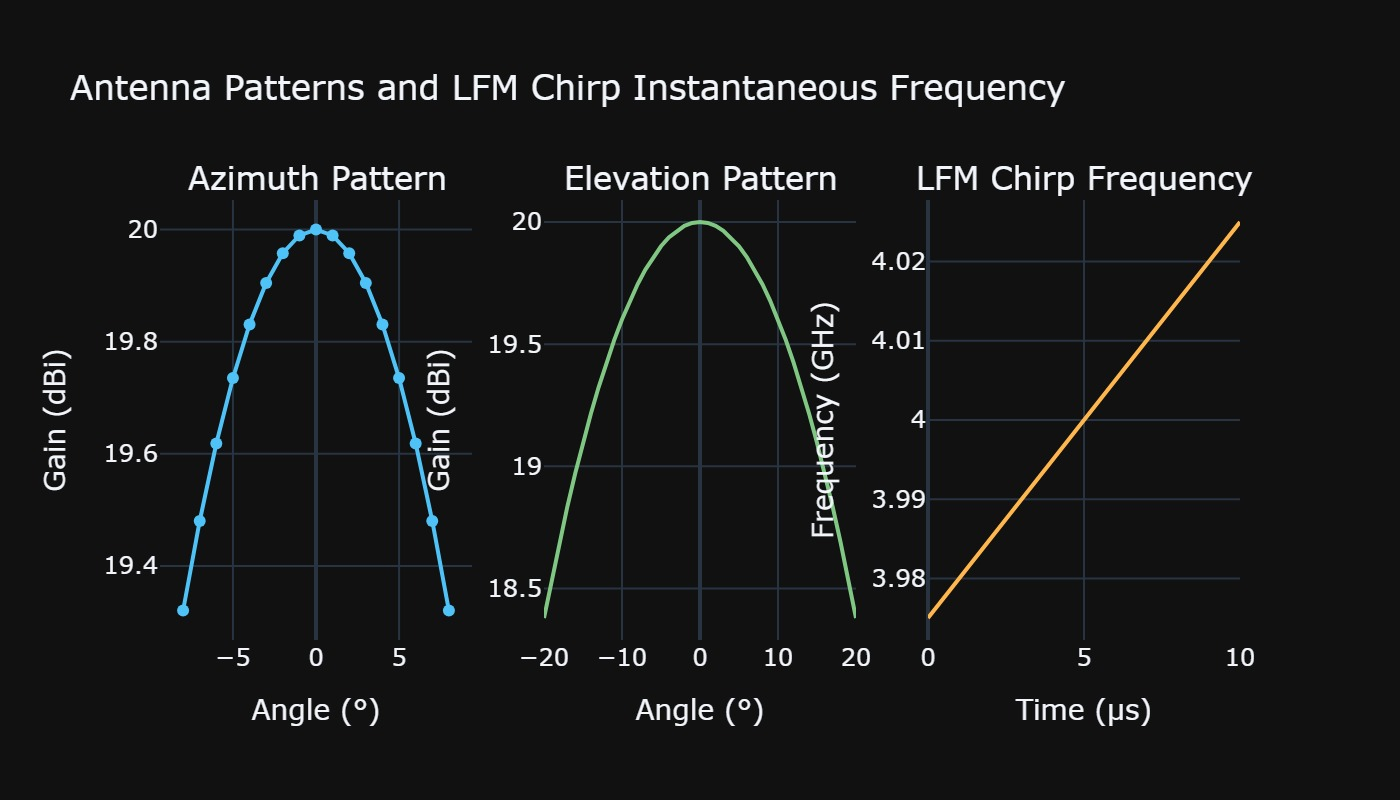

In [27]:
t_chirp = np.linspace(0, tpd, 500)
inst_freq_ghz = (fc + (bw / tpd) * (t_chirp - tpd / 2)) / 1e9  # instantaneous frequency

fig = make_subplots(
    rows=1,
    cols=3,
    subplot_titles=("Azimuth Pattern", "Elevation Pattern", "LFM Chirp Frequency"),
)

fig.add_trace(
    go.Scatter(x=az_angle, y=az_pattern, line=dict(color="#4FC3F7", width=2)),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(x=el_angle, y=el_pattern, line=dict(color="#81C784", width=2)),
    row=1,
    col=2,
)
fig.add_trace(
    go.Scatter(
        x=t_chirp * 1e6,
        y=inst_freq_ghz,
        line=dict(color="#FFB74D", width=2),
    ),
    row=1,
    col=3,
)

fig.update_xaxes(title_text="Angle (°)", row=1, col=1)
fig.update_xaxes(title_text="Angle (°)", row=1, col=2)
fig.update_xaxes(title_text="Time (µs)", row=1, col=3)
fig.update_yaxes(title_text="Gain (dBi)", row=1, col=1)
fig.update_yaxes(title_text="Gain (dBi)", row=1, col=2)
fig.update_yaxes(title_text="Frequency (GHz)", row=1, col=3)

fig.update_layout(
    title="Antenna Patterns and LFM Chirp Instantaneous Frequency",
    template="plotly_dark",
    height=400,
    showlegend=False,
)
show(fig)

In [28]:
rx_channel = dict(
    location=(0, 0, 0),
    azimuth_angle=az_angle,
    azimuth_pattern=az_pattern,
    elevation_angle=el_angle,
    elevation_pattern=el_pattern,
)

rx = Receiver(
    fs=fs,
    noise_figure=5,  # NF = 5 dB
    rf_gain=20,  # LNA gain = 20 dB
    baseband_gain=30,  # Baseband gain = 30 dB
    channels=[rx_channel],
)

print("Receiver configured.")
print(f"  Sample rate      : {fs/1e6:.0f} MHz")
print(f"  Samples per pulse: {pulse_samples}")

Receiver configured.
  Sample rate      : 500 MHz
  Samples per pulse: 5000


### Platform Trajectory & Scene

The platform flies straight and level along **+x** at 150 m/s, offset **2,000 m in cross-track** from the near edge of the swath and **3,200 m above sea level** (≈2,250 m above the flat reference elevation `z_ref` used later for imaging). The antenna boresight is yawed 90° to look broadside (+y) and pitched down by the ≈31° centre depression angle.

The flight is split into `n_segments` back-to-back stretches, each independently under the duration/pulse-count limits described above, with the next segment's platform positions picking up exactly where the previous one left off:

| Parameter | Value |
|---|---|
| Per-segment flight | 600 m flown, 4.0 s duration, PRF≈220 Hz, 880 pulses |
| Chained flight | 3 segments -> x ∈ [cx−900, cx+900] m (1,800 m total), y = 20,000 m, z = 3,200 m |
| Depression angle | ≈48° (near) → ≈31° (centre) → ≈22° (far) |
| Reference elevation `z_ref` | 950 m — assumed **flat** by Back-Projection; this is what creates layover |

Unlike the point-target notebook's three isolated scatterers, the "target" here is the terrain itself: every facet of `grand_canyon.stl` within the illuminated footprint contributes a return.

In [29]:
# Platform flies along +x. Precompute the FULL, multi-segment flight path now (pure
# geometry -- no simulation needed yet) so it can be visualised before we get to the
# expensive part, and reused later to set each segment's motion during simulation.
segment_centers = cx - total_flight_length / 2 + synthetic_aperture * (np.arange(n_segments) + 0.5)

pulse_times = np.arange(num_pulses) * prp
pulse_times -= pulse_times.mean()

platform_x = np.concatenate([seg_center + v_platform * pulse_times for seg_center in segment_centers])
num_pulses_total = len(platform_x)

print(f"Chaining {n_segments} segments x {num_pulses} pulses = {num_pulses_total} pulses total")
print(f"Segment centres (x): {np.array2string(segment_centers, precision=1)}")
print(f"Full flight span: x = {platform_x.min():.1f} to {platform_x.max():.1f} m "
      f"({platform_x.max()-platform_x.min():.0f} m)")

Chaining 10 segments x 880 pulses = 8800 pulses total
Segment centres (x): [16779. 17379. 17979. 18579. 19179. 19779. 20379. 20979. 21579. 22179.]
Full flight span: x = 16479.3 to 22478.7 m (5999 m)


In [30]:
radar = Radar(
    transmitter=tx,
    receiver=rx,
)

# Motion is NOT set here -- each segment gets its own radar.set_motion(...) call during
# simulation (below), reusing this same Radar object with a fresh set of positions.

print(f"Radar created. {n_segments} segments x {num_pulses} pulses each = {num_pulses_total} pulses total.")
print(f"  Platform y={y_fly:.0f} m, z={z_fly:.0f} m")
print(f"  Boresight: yaw=90 deg (+y broadside), pitch={-dep_center:.1f} deg (elevation tilt)")

Radar created. 10 segments x 880 pulses each = 8800 pulses total.
  Platform y=20000 m, z=3200 m
  Boresight: yaw=90 deg (+y broadside), pitch=-31.0 deg (elevation tilt)


In [31]:
target = {
    "model": "../models/grand_canyon.stl",  # full terrain mesh (not cropped for simulation)
    "unit": "m",
    "location": (0, 0, 0),  # native STL coordinates -- our flight geometry is placed within them
    "speed": (0, 0, 0),
    "permittivity": 5,  # soil-like dielectric, matching scene_pulse_radar_altimeter.ipynb
}
targets = [target]

print("Target: Grand Canyon terrain mesh (grand_canyon.stl)")
print(f"  Illuminated swath: y = {y0:.0f} to {y1:.0f} m (cross-track)")
print(f"  Local elevation: ~531 to ~1655 m")

Target: Grand Canyon terrain mesh (grand_canyon.stl)
  Illuminated swath: y = 22000 to 25500 m (cross-track)
  Local elevation: ~531 to ~1655 m


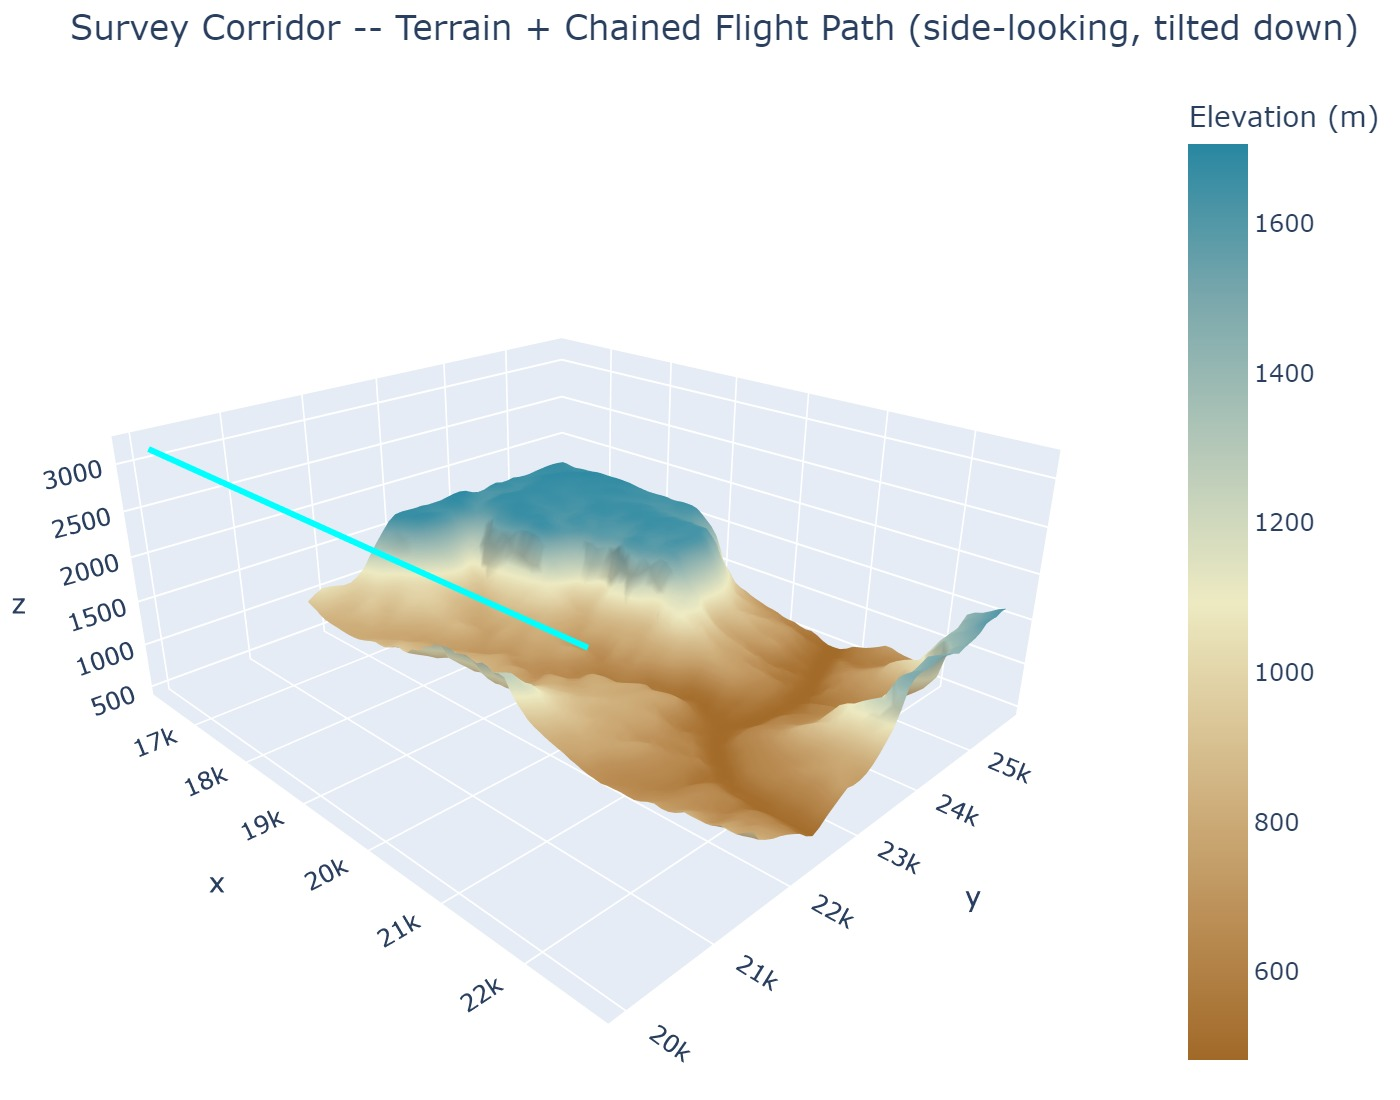

In [32]:
# -- Crop a local patch purely for 3D visualisation (simulation still uses the full mesh) ---
vis_mask = (
    (verts[:, 0] >= cx - total_flight_length / 2 - 200) & (verts[:, 0] <= cx + total_flight_length / 2 + 200)
    & (verts[:, 1] >= y0 - 300) & (verts[:, 1] <= y1 + 300)
)
face_mask = vis_mask[faces[:, 0]] & vis_mask[faces[:, 1]] & vis_mask[faces[:, 2]]
f_vis = faces[face_mask]
used = np.unique(f_vis.ravel())
remap = -np.ones(verts.shape[0], dtype=np.int64)
remap[used] = np.arange(used.size)
v_vis = verts[used]
f_vis = remap[f_vis]

fig = go.Figure()
fig.add_trace(
    go.Mesh3d(
        x=v_vis[:, 0], y=v_vis[:, 1], z=v_vis[:, 2],
        i=f_vis[:, 0], j=f_vis[:, 1], k=f_vis[:, 2],
        intensity=v_vis[:, 2], colorscale="Earth",
        colorbar=dict(title="Elevation (m)"), name="Terrain",
    )
)
fig.add_trace(
    go.Scatter3d(
        x=platform_x,
        y=np.full_like(platform_x, y_fly),
        z=np.full_like(platform_x, z_fly),
        mode="lines",
        line=dict(color="cyan", width=6),
        name="Flight path",
    )
)

fig.update_layout(
    title="Survey Corridor -- Terrain + Chained Flight Path (side-looking, tilted down)",
    scene=dict(aspectmode="data", camera=dict(eye=dict(x=1.6, y=-1.6, z=1.0))),
    height=550,
    margin=dict(l=5, r=0, b=10, t=40),
)
show(fig)

## Simulation & SAR Processing

`sim_radar` ray-traces the LFM chirp against the full 771,288-facet terrain mesh. Because a single call is capped at 880 pulses (4.0 s of simulated flight), reaching the full 1,800 m flight means calling it **three times** — once per segment, each with its own `radar.set_motion(...)` picking up exactly where the previous segment's platform position left off. Ray density stays at `density=0.02` and thermal noise is added to each segment's baseband as before. Expect the three segments together to take roughly 15-18 minutes.

SAR processing has the same first stage as the point-target notebook, but a different second stage:

1. **Range Compression (Fast-Time FFT)** — run once per segment (immediately after that segment's `sim_radar` call), then concatenated into one combined range-compressed pulse train covering the whole chained flight.
2. **Sliding-Window Back-Projection** — instead of summing the *entire* flight for every pixel, each pixel is focused only from the pulses within its own real-beam footprint (a window that slides along with the along-track position), with a smooth raised-cosine taper across that local window. The two-way range still includes the fixed **vertical** term from the flat-earth reference:

$$R_n = \sqrt{(x_p-x_n)^2 + (y_p-y_{fly})^2 + (z_{ref}-z_{fly})^2}$$

BPA assumes every image pixel sits at the same flat reference elevation $z_{ref}$, even though the real terrain does not. That mismatch between the assumed flat reference and the true 3-D scattering geometry is exactly what produces relief displacement (layover) in the final image.

In [33]:
# -- Range compression setup: identical for every segment, computed once -------------
range_win = scipy.signal.windows.chebwin(pulse_samples, at=50)
NFFT = pulse_samples * 4  # zero-padding -> finer range grid
freq_axis = np.fft.fftshift(np.fft.fftfreq(NFFT, d=1 / fs))
range_axis_full = freq_axis * c * tpd / (2 * bw)
range_window_lo, range_window_hi = R_near - 300, R_far + 300
range_mask = (range_axis_full >= range_window_lo) & (range_axis_full <= range_window_hi)
range_axis = range_axis_full[range_mask]

# -- Chain sim_radar calls: one per segment, each under the duration/pulse limits ----
# Each segment reuses the SAME radar object, just with a fresh set_motion(...) call
# continuing on from where the previous segment's platform positions left off.
t_offset = (num_pulses - 1) / 2 * prp
range_profile_list = []
tic_total = time.time()
for seg_idx, seg_center in enumerate(segment_centers):
    seg_locations = [seg_center + (radar.time_prop["timestamp"] - t_offset) * v_platform, y_fly, z_fly]
    radar.set_motion(location=seg_locations, rotation=[90, -dep_center, 0])

    tic = time.time()
    data = sim_radar(radar, targets, density=0.02, level="pulse")
    # Add thermal noise -- without it the background is pure silence (0), which looks
    # artificially clean; real SAR imagery always has a speckled noise floor.
    baseband_seg = data["baseband"] + data["noise"]
    print(f"  segment {seg_idx+1}/{n_segments} (centre x={seg_center:.0f} m): "
          f"sim time {time.time()-tic:.0f} s")

    raw_seg = baseband_seg[0, :, :]
    range_profile_full_seg = np.fft.fftshift(
        np.fft.fft(raw_seg * range_win[np.newaxis, :], NFFT, axis=1), axes=1
    )
    range_profile_list.append(range_profile_full_seg[:, range_mask])

range_profile = np.concatenate(range_profile_list, axis=0)

print(f"All {n_segments} segments complete in {time.time()-tic_total:.0f} s total.")
print(f"  Combined range_profile shape: {range_profile.shape}  (num_pulses_total x range_bins)")
print(f"  Range axis: {range_axis[0]:.1f} to {range_axis[-1]:.1f} m")
print(f"  Range resolution after compression: {range_res:.2f} m")

  segment 1/10 (centre x=16779 m): sim time 297 s
  segment 2/10 (centre x=17379 m): sim time 312 s
  segment 3/10 (centre x=17979 m): sim time 323 s
  segment 4/10 (centre x=18579 m): sim time 337 s
  segment 5/10 (centre x=19179 m): sim time 335 s
  segment 6/10 (centre x=19779 m): sim time 2462 s
  segment 7/10 (centre x=20379 m): sim time 348 s
  segment 8/10 (centre x=20979 m): sim time 356 s
  segment 9/10 (centre x=21579 m): sim time 361 s
  segment 10/10 (centre x=22179 m): sim time 360 s
All 10 segments complete in 5498 s total.
  Combined range_profile shape: (8800, 4713)  (num_pulses_total x range_bins)
  Range axis: 2710.9 to 6242.4 m
  Range resolution after compression: 3.00 m


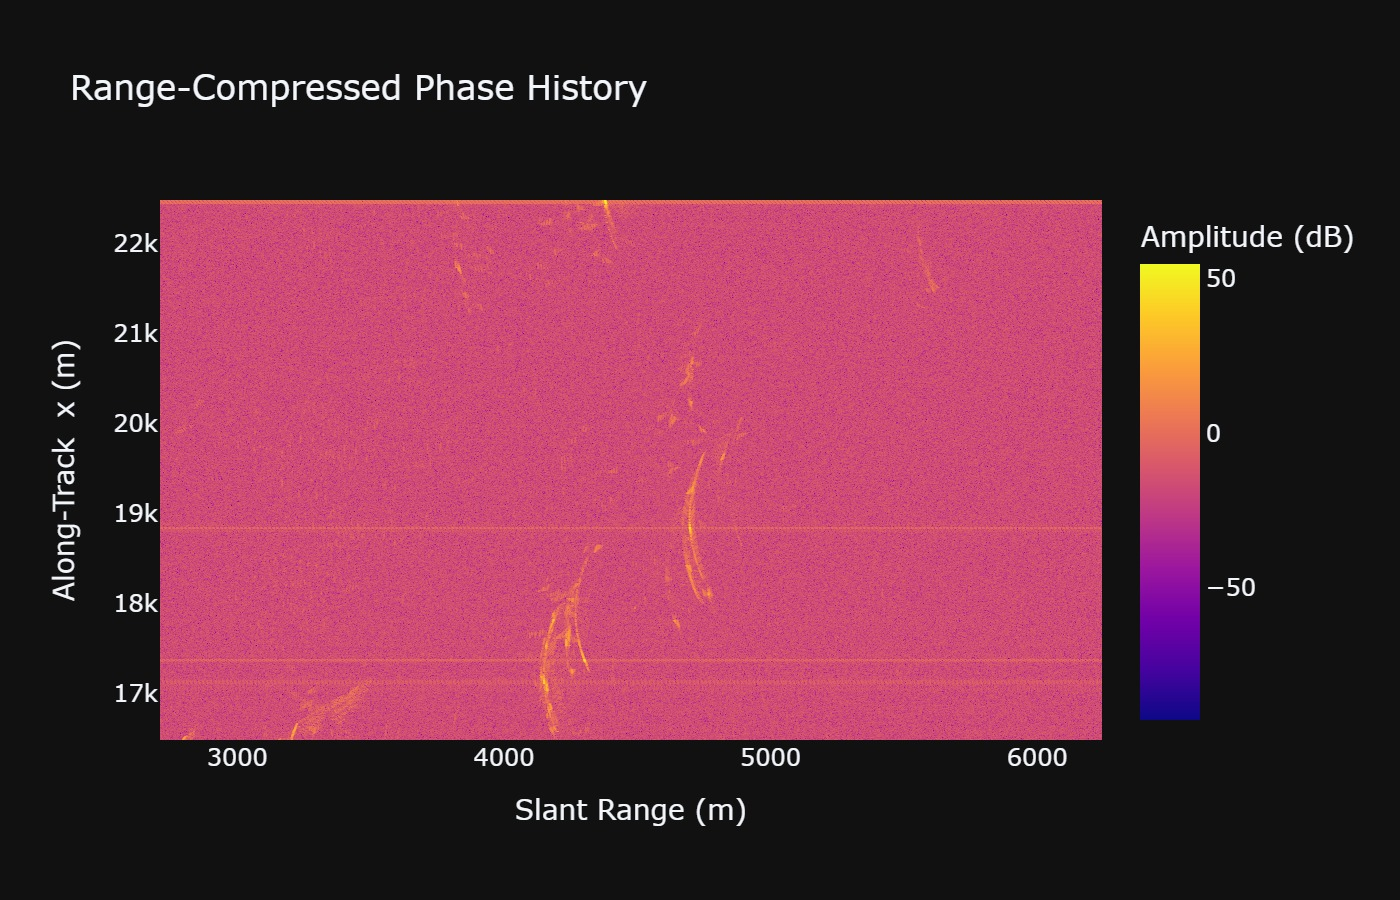

In [34]:
fig = go.Figure()
fig.add_trace(
    go.Heatmap(
        x=range_axis,
        y=platform_x,
        z=20 * np.log10(np.abs(range_profile) + 1e-12),
        colorscale="Plasma",
        colorbar=dict(title="Amplitude (dB)"),
    )
)
fig.update_layout(
    title="Range-Compressed Phase History",
    xaxis_title="Slant Range (m)",
    yaxis_title="Along-Track  x (m)",
    template="plotly_dark",
    height=450,
)
show(fig)

### Step 2: Sliding-Window Stripmap Focusing

For each pulse at along-track position $x_n$, only the image columns within $\pm$ half the real-beam footprint of $x_n$ can possibly see that pulse in reality, so only those columns receive its contribution. A **raised-cosine (Hann-shaped) taper**, continuous in distance rather than a fixed-length discrete window, smoothly rolls each pulse's contribution to zero at the edge of its footprint — this both controls azimuth sidelobes and avoids any hard cliff as pulses enter/exit a pixel's dwell.

This is the opposite computational trade-off from the earlier global-sum version: instead of iterating every pulse over the *entire* image (expensive, and it's what forced pulse count to scale with aperture²), each pulse now only touches a narrow local slice of the image — cheaper per pulse, and the achievable swath length no longer depends on how many pulses the license allows per call.

In [35]:
# -- Image grid ---------------------------------------------------------------
img_ranges = np.arange(y0, y1 + range_res, range_res)

half_footprint = footprint_length / 2
az_window = total_flight_length / 2 + half_footprint  # pixels just past the flight ends still get partial dwell
az_step = 1.0  # m -- much finer than az_res_stripmap is unnecessary and costly; this is for display smoothness
img_az = np.arange(cx - az_window, cx + az_window + az_step, az_step)

print(f"Image grid: {len(img_az)} az x {len(img_ranges)} range pixels")
print(f"  Azimuth : {img_az[0]:.1f} to {img_az[-1]:.1f} m  (step {az_step:.2f} m)")
print(f"  Range   : {img_ranges[0]:.1f} to {img_ranges[-1]:.1f} m  (step {range_res:.2f} m)")

# -- Sliding-window stripmap Back-Projection ------------------------------------
# Each pulse only contributes to the image columns within its real-beam footprint
# (a window that slides with along-track position), weighted by a continuous
# raised-cosine taper -- NOT a global sum over the whole flight for every pixel.
# platform_x / range_profile now span ALL chained segments (num_pulses_total pulses).
dz_ref = z_fly - z_ref  # fixed vertical offset: flat-earth reference vs. flight altitude
sar_image = np.zeros((len(img_az), len(img_ranges)), dtype=complex)
tic_bpa = time.time()
for pulse_idx in range(num_pulses_total):
    x_n = platform_x[pulse_idx]

    # Image columns within this pulse's real-beam footprint
    lo = np.searchsorted(img_az, x_n - half_footprint, side="left")
    hi = np.searchsorted(img_az, x_n + half_footprint, side="right")
    if hi <= lo:
        continue
    az_local = img_az[lo:hi]

    # Continuous raised-cosine (Hann-shaped) taper vs. normalised distance from x_n
    u = (az_local - x_n) / half_footprint
    w_local = 0.5 * (1.0 + np.cos(np.pi * u))

    dx = az_local - x_n
    dy = img_ranges[:, np.newaxis] - y_fly
    R_n = np.sqrt(dx[np.newaxis, :] ** 2 + dy**2 + dz_ref**2)  # (n_ranges, n_local_az)

    interp_fn = interp1d(range_axis, range_profile[pulse_idx], kind="linear",
                          bounds_error=False, fill_value=0)
    interp_sig = interp_fn(R_n.ravel()).reshape(R_n.shape)
    phase_corr = np.exp(-1j * 4.0 * np.pi * R_n / lam)

    sar_image[lo:hi, :] += (w_local[np.newaxis, :] * interp_sig * phase_corr).T
toc_bpa = time.time()

print(f"Back-projection complete in {toc_bpa - tic_bpa:.0f} s.")
print(f"  SAR image shape : {sar_image.shape}  (Naz x Nr)")

Image grid: 6225 az x 1169 range pixels
  Azimuth : 16367.2 to 22591.2 m  (step 1.00 m)
  Range   : 22000.0 to 25501.6 m  (step 3.00 m)
Back-projection complete in 295 s.
  SAR image shape : (6225, 1169)  (Naz x Nr)


## Results: Focused SAR Image

The focused image (normalised power, dB) shows a series of bright bands, each corresponding to a distinct terrain feature — a ridge, a ledge, a valley floor — within the swath. Unlike the point-target notebook, these bands are **not** at their true (x, y) ground position: Back-Projection assumed a flat reference elevation, so any real terrain that sits above or below that reference is displaced in range. Rim features (above `z_ref`) shift toward the radar (shorter apparent range); canyon-floor features (below `z_ref`) shift away.

With the sliding-window fix and the chained 1,800 m flight (3 segments of 600 m each), the along-track (x) axis has much more room to show genuine variation than any single `sim_radar` call could reach on its own — real terrain features shifting position or appearing/disappearing as the flight crosses different parts of the corridor. The layover check below still validates the range-displacement physics quantitatively.

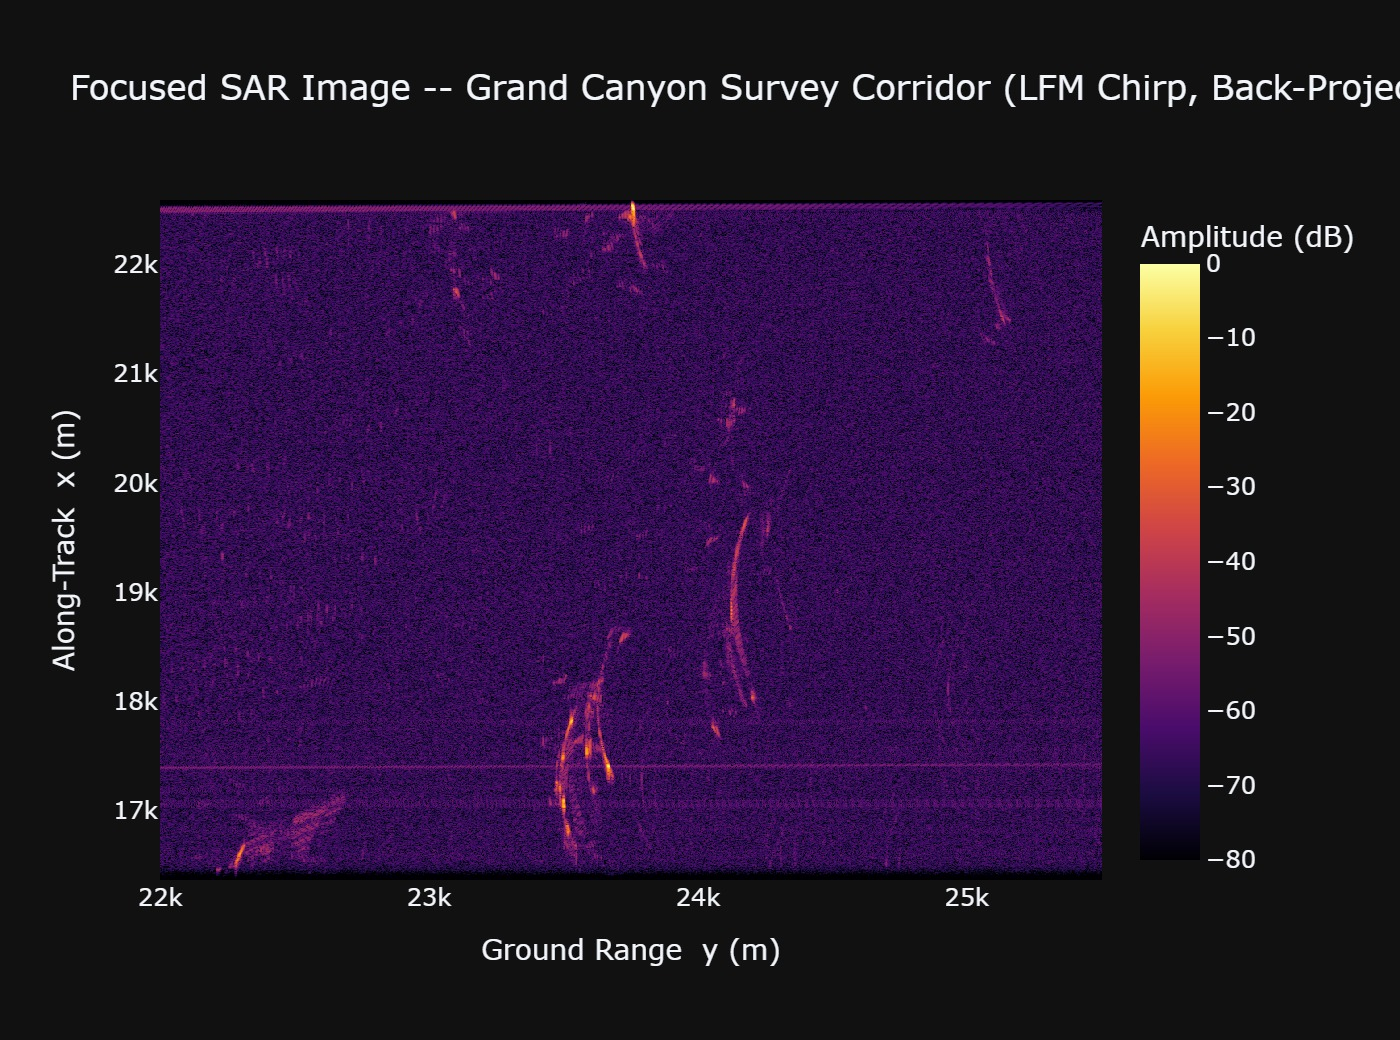

In [41]:
sar_amp_db = 20 * np.log10(np.abs(sar_image) + 1e-12)
sar_amp_db -= sar_amp_db.max()  # normalise to 0 dB

fig = go.Figure()
fig.add_trace(
    go.Heatmap(
        x=img_ranges,
        y=img_az,
        z=sar_amp_db,
        colorscale="Inferno",
        colorbar=dict(title="Amplitude (dB)"),
        zmin=-80,
        zmax=0,
    )
)

fig.update_layout(
    title="Focused SAR Image -- Grand Canyon Survey Corridor (LFM Chirp, Back-Projection)",
    xaxis_title="Ground Range  y (m)",
    yaxis_title="Along-Track  x (m)",
    template="plotly_dark",
    height=520,
)
show(fig)

## Layover Check: True Terrain vs. Imaged Position

Because Back-Projection assumes every pixel sits at the flat reference elevation `z_ref`, a real point at true ground range $y_{true}$ and true elevation $z_{true}$ is not imaged at $y_{true}$ — it appears at

$$y_{pred} = y_{fly} + \sqrt{R_{true}^2 - (z_{ref}-z_{fly})^2}, \qquad R_{true} = \sqrt{(y_{true}-y_{fly})^2 + (z_{true}-z_{fly})^2}$$

We sample the true terrain elevation directly from the STL along the flight's along-track centreline (`x ≈ cx`) and compare each point's *predicted* image position against the actual bright bands in the focused SAR image.

In [37]:
# -- Sample the true terrain profile along the flight centreline (x ~ cx) ----
prof_mask = (
    (np.abs(verts[:, 0] - cx) < 200) & (verts[:, 1] >= y0 - 100) & (verts[:, 1] <= y1 + 100)
)
y_true = verts[prof_mask, 1]
z_true = verts[prof_mask, 2]
order = np.argsort(y_true)
y_true, z_true = y_true[order], z_true[order]

R_true = np.sqrt((y_true - y_fly) ** 2 + (z_fly - z_true) ** 2)
y_pred = y_fly + np.sqrt(np.maximum(R_true**2 - dz_ref**2, 0))

# -- Actual SAR image cross-section through the flight centreline ------------
az_center_idx = np.argmin(np.abs(img_az - cx))
image_cut_db = 20 * np.log10(np.abs(sar_image[az_center_idx, :]) + 1e-12)
image_cut_db -= image_cut_db.max()

# -- Quantitative check: does the brightest imaged feature line up with the ---
# -- true terrain point predicted to displace to that location? --------------
peaks, _ = find_peaks(image_cut_db, height=-25, distance=max(int(20 / range_res), 1))
peak_y = img_ranges[peaks]
peak_db = image_cut_db[peaks]
main_idx = np.argmax(peak_db)
nearest = np.argmin(np.abs(y_pred - peak_y[main_idx]))

print(f"Brightest imaged feature: y_p = {peak_y[main_idx]:.0f} m ({peak_db[main_idx]:.1f} dB)")
print(f"  Nearest true-terrain match : y_true = {y_true[nearest]:.0f} m, z_true = {z_true[nearest]:.0f} m")
print(f"  Predicted image position  : y_pred = {y_pred[nearest]:.0f} m")
print(f"  Layover displacement      : {y_pred[nearest] - y_true[nearest]:+.0f} m "
      f"({'toward' if y_pred[nearest] < y_true[nearest] else 'away from'} the radar)")

Brightest imaged feature: y_p = 24060 m (0.0 dB)
  Nearest true-terrain match : y_true = 24000 m, z_true = 844 m
  Predicted image position  : y_pred = 24061 m
  Layover displacement      : +61 m (away from the radar)


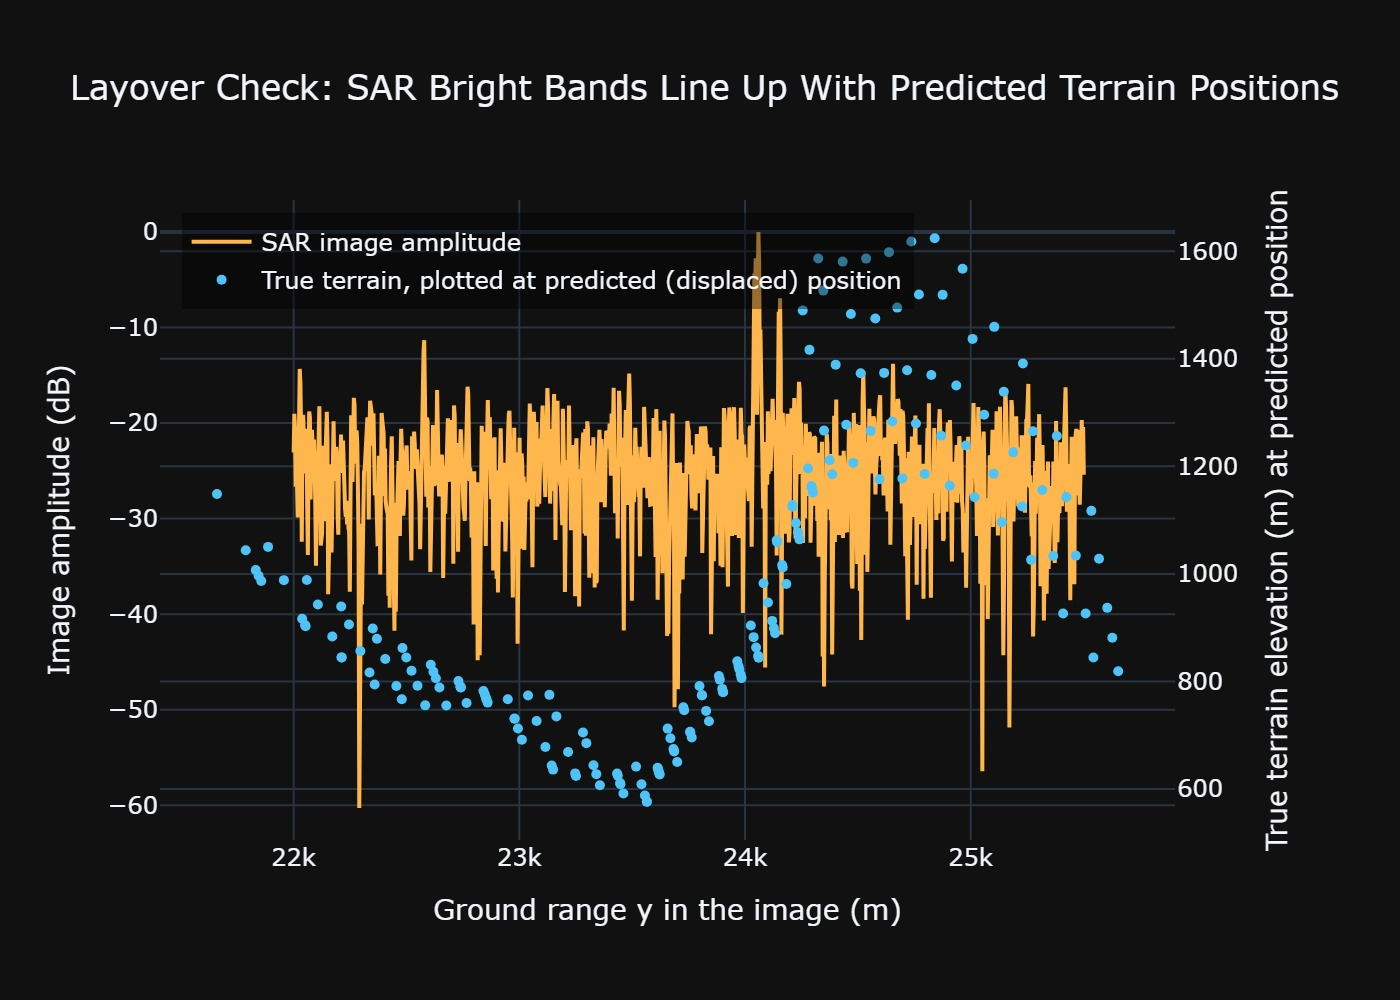

In [38]:
fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(
    go.Scatter(
        x=img_ranges, y=image_cut_db, name="SAR image amplitude",
        line=dict(color="#FFB74D", width=2),
    )
)
fig.add_trace(
    go.Scatter(
        x=y_pred, y=z_true, name="True terrain, plotted at predicted (displaced) position",
        mode="markers", marker=dict(color="#4FC3F7", size=5),
    ),
    secondary_y=True,
)
fig.update_xaxes(title_text="Ground range y in the image (m)")
fig.update_yaxes(title_text="Image amplitude (dB)", secondary_y=False)
fig.update_yaxes(title_text="True terrain elevation (m) at predicted position", secondary_y=True)
fig.update_layout(
    title="Layover Check: SAR Bright Bands Line Up With Predicted Terrain Positions",
    template="plotly_dark",
    height=500,
    legend=dict(x=0.02, y=0.98, bgcolor="rgba(0,0,0,0.4)"),
)
show(fig)

## Summary

This notebook extended the C-band stripmap LFM SAR simulation from `waveform_lfm_sar.ipynb` to a **real terrain mesh** (`grand_canyon.stl`) instead of idealized point targets:

| Stage | Key Parameters | Result |
|---|---|---|
| Terrain scouting | 771k-facet DEM, ~50×62 km | Selected a 3.5 km cross-canyon corridor, ≈531–1655 m relief |
| Waveform | $f_c$=4 GHz, B=50 MHz, τ=10 μs | ΔR=3 m; stretched pulse keeps `fs` at 500 MHz despite ~3-6 km slant range |
| Flight geometry | v=150 m/s, 3 segments x 880 pulses, alt=3200 m, standoff 2000 m | 1,800 m chained flight (PRF≈220 Hz, each segment duration-capped at 4.0 s) |
| Radar hardware | narrow azimuth (1.5 m antenna, ±8°), wide elevation (cos³, ±20°) | beamwidths matched to the real illumination geometry |
| Simulation | full mesh ray-traced 3x, `density=0.02`, thermal noise added each segment | ~15-18 minutes' runtime against 771,288 facets |
| Range compression | fast-time FFT, Chebyshev window, per segment then concatenated | ΔR=3 m |
| Image formation | **sliding-window stripmap BPA** over the combined pulse train + flat `z_ref`=950 m | reveals real terrain — **with layover** — across a swath 3x longer than one `sim_radar` call could reach |
| Validation | true STL elevation vs. predicted image position | bright bands match the predicted layover position |

### Grand Canyon SAR vs. the Point-Target Notebook

The point-target notebook's Back-Projection focuses perfectly because every target really does sit at $z=0$, matching the flat reference the algorithm assumes. Real terrain breaks that assumption: a canyon rim towering ~700 m above the reference elevation returns its energy at a *shorter* range than a flat-earth pixel at the same ground coordinate would, so BPA places it too close to the radar. This is **relief displacement (layover)** — a real, well-documented artifact in airborne and spaceborne SAR imagery of mountainous terrain, and true ortho-rectification requires knowing (or jointly estimating, as in InSAR) the actual terrain elevation, not a single flat reference.

### Three Fixes to Get Here: Sliding-Window Stripmap, a Duration Limit, and Chaining

Earlier passes through this notebook summed the *entire* flight as one synthetic aperture for every pixel (spotlight-style), which forces pulse count to scale with the *square* of the aperture length. **Sliding-window stripmap focusing** fixed that — each pixel is focused only from the pulses inside its own real-beam footprint, decoupling swath length from the aperture-squared penalty.

That surfaced a second problem: pushing pulse count to the full 1,600-pulse license budget meant a 7.3 s simulated flight, and this evaluation build of `sim_radar` **silently stops updating platform motion after ≈5.0 s**, quietly re-returning stale, bit-for-bit identical data instead of erroring. That produced a focused image with one suspiciously perfect, dead-straight bright line — tracked down by ruling out normalization, sliding-window coverage bugs, sharp terrain features, and facet-orientation effects one at a time. The fix was to cap each `sim_radar` call's duration at 4.0 s, which alone limited any single call to a ≈600 m swath.

Neither limit — pulse count nor duration — is about *total* flight length, though; they're both per-call. So this version **chains three `sim_radar` calls**, each independently safe (880 pulses, 4.0 s), with each segment's `radar.set_motion(...)` picking up exactly where the previous one's platform positions left off. The range-compressed results are concatenated into one combined pulse train and back-projected together, reaching 1,800 m total — 3x what any single call could produce, without touching either limit.

### Things to Try

| Experiment | How | Observable effect |
|---|---|---|
| Remove layover | Look up the true elevation per-pixel from the STL instead of a constant `z_ref` | Terrain-corrected ("ortho-rectified") image |
| Even wider swath | Increase `n_segments` further | Longer flight, proportionally longer runtime |
| Different canyon feature | Change `cx`, `y0`, `y1` | Different relief profile and layover pattern |
| Steeper standoff | Reduce `y_fly` (larger depression angles) | More pronounced layover, different near/far resolution |
| Higher fidelity | Increase `density` further (accepting a longer runtime) | Less speckled terrain return, better facet-level detail |